<a href="https://colab.research.google.com/github/DebbieJara/rappiplus-revenue-retention-analysis/blob/main/RappiPlus_Analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## 🔹 Paso 1: Carga y validación de calidad de datos

Los datasets `rappiplus_orders_raw.csv`, `rappiplus_catalog.csv` y `rappiplus_marketing_spend.csv` fueron cargados y explorados para identificar su estructura, tipos de datos y posibles inconsistencias antes de la limpieza.

In [109]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [110]:
# Load datasets
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [111]:
# Explore 'orders' dataset
print('Orders Dataset:')
print()
print('Shape:')
print(orders.shape)
print()
print('Info:')
orders.info()
print()
print('Sample:')
orders.head(10)

Orders Dataset:

Shape:
(25100, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

Sample:


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28
5,order_5,user_2792,2025-04-22,mexico,desktop,organic,Tablet-Standard-64GB,Electronica,1.0,179.34,0.0,179.34
6,order_6,user_2802,2025-03-15,Colombia,mobile,organic,Blender-XL-Red,Hogar,2.0,163.59,0.0,327.19
7,order_7,user_1083,2025-05-01,Mexico,desktop,organic,Tablet-Standard-64GB,Electronica,2.0,373.68,0.0,747.35
8,order_8,user_2352,2025-03-01,Argentina,desktop,paid_search,Laptop-Gaming-16GB,Electronica,2.0,477.27,5.0,949.54
9,order_9,user_7001,2025-05-31,Mexico,mobile,organic,Sneakers-Urban-42,Moda,1.0,339.30,5.0,334.30


In [112]:
# Check for missing values
print('Nulls:')
print(orders.isnull().sum())

Nulls:
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64


### Valores nulos en `orders`

Al revisar `orders.isnull().sum()`, se identificaron 8 columnas con valores
nulos:

- `pais`: 300
- `categoria_producto`: 80
- `cantidad`: 50
- `precio_unitario`: 50
- `monto_descuento`: 50
- `fuente_referencia`: 30
- `nombre_producto`: 30
- `dispositivo`: 20

A continuación se investigó si estos nulos están relacionados entre sí
(es decir, si las mismas filas presentan varios nulos a la vez) o si
corresponden a problemas independientes, para poder decidir el tratamiento
adecuado de cada grupo en la limpieza.

In [113]:
# Check rows where 'cantidad' is missing
orders[orders['cantidad'].isnull()].head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,595.85
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,458.15
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,NaN,NaN,NaN,NaN,319.75
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,227.55
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,NaN,NaN,NaN,NaN,432.39


In [114]:
# Verify that all rows with missing 'cantidad' also have 'precio_unitario' and 'monto_descuento' missing
orders[(orders['cantidad'].isnull()) & (orders['precio_unitario'].isnull()) & (orders['monto_descuento'].isnull())].shape[0]

50

### Análisis de valores nulos en columnas numéricas

Las columnas `cantidad`, `precio_unitario` y `monto_descuento` tienen
exactamente 50 valores nulos cada una. Se verificó con evidencia que
corresponden a las mismas 50 filas en los tres casos (confirmado con
`.shape[0]` = 50), lo que sugiere que son pedidos con información
incompleta capturada desde el origen, y no nulos independientes en
cada columna.

Esto se resolverá en la sección de limpieza de datos.

In [115]:
# Check for invalid values (zero or negative) in numeric columns
print('Cantidad:', orders[orders['cantidad'] <= 0].shape[0])
print('Precio Unitario:', orders[orders['precio_unitario'] <= 0].shape[0])
print('Monto Descuento:', orders[orders['monto_descuento'] < 0].shape[0])
print('Monto total:', orders[orders['monto_total'] <= 0].shape[0])

Cantidad: 4
Precio Unitario: 0
Monto Descuento: 0
Monto total: 4


In [116]:
# Check for invalid values (negative or zero) in 'cantidad' and 'monto_total'
orders[(orders['cantidad'] <=0) & (orders['monto_total'] <=0)].shape[0]

4

In [117]:
# View full rows with invalid 'cantidad' or 'monto_total' to inspect the pattern
orders[(orders['cantidad'] <=0) | (orders['monto_total'] <=0)]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [118]:

# Check distribution of 'cantidad' to investigate extreme outliers found in monto_total
orders['cantidad'].describe()


,cantidad
count,25050.000000
mean,7.092735
std,296.277003
min,-2.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,20000.000000


In [119]:
# Check for unusually high 'cantidad' values
orders[orders['cantidad'] > 10]['cantidad'].value_counts()

,count
cantidad,
10000.0,6
20000.0,4


### Valores inválidos en columnas numéricas de `orders`

Se revisaron `cantidad`, `precio_unitario`, `monto_descuento` y `monto_total`
en busca de valores negativos, iguales a cero, o excesivamente altos:

- **`cantidad`**: 4 filas con valores negativos (-1 o -2), y 10 filas con
  valores extremadamente altos (10,000 o 20,000 unidades), sin ningún valor
  intermedio entre 3 y 9,999.
- **`monto_total`**: 4 filas con valores negativos, coincidiendo con las
  mismas filas de `cantidad` negativa.
- **`precio_unitario`**: sin valores inválidos.
- **`monto_descuento`**: sin valores negativos.

No hay información adicional en el dataset que explique el origen de ninguno
de estos valores atípicos. Se decidirá en la limpieza si conviene eliminar
ambos grupos de filas (14 en total, 0.06% del dataset), dado lo mínimo de su
impacto y la falta de evidencia para corregirlos con confianza.

In [120]:
# Check rows where 'categoria_producto' is missing
orders[orders['categoria_producto'].isnull()].head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
44,order_44,user_2899,2025-02-22,Colombia,desktop,NaN,NaN,NaN,1.0,318.38,5.0,313.38
45,order_45,user_6196,2025-02-10,Mexico,mobile,NaN,NaN,NaN,2.0,354.06,10.0,698.12
46,order_46,user_5815,2025-04-24,Mexico,mobile,NaN,NaN,NaN,1.0,359.31,10.0,349.31
47,order_47,user_406,2025-05-08,Colombia,mobile,NaN,NaN,NaN,2.0,476.78,0.0,953.56
48,order_48,user_6187,2025-01-26,Colombia,desktop,NaN,NaN,NaN,2.0,137.96,0.0,275.93


In [121]:
# Check rows where 'categoria_producto' is missing but 'nombre_producto' is present (potentially recoverable via 'catalog')
orders[(orders['categoria_producto'].isnull()) & (orders['nombre_producto'].notnull())].shape[0]

50

In [122]:

# Check rows where both 'categoria_producto' and 'nombre_producto' are missing (not recoverable)
orders[(orders['categoria_producto'].isnull()) & (orders['nombre_producto'].isnull())].shape[0]


30

#### Nulos en `categoria_producto`

De los 80 valores nulos en `categoria_producto`, se identificaron dos grupos
distintos:

- **30 filas** donde nombre_producto también está vacío. Al no contar con el nombre del producto, no es posible recuperar la categoría cruzando con el dataset catalog. Dado que sí cuentan con monto_total (revenue real), se decidió conservarlas y rellenar categoria_producto con "Sin categoría" en la limpieza, en vez de descartar ese ingreso del análisis. qué tal así?
- **50 filas** donde `nombre_producto` sí está presente, pero falta
  únicamente la categoría. Este grupo es recuperable: la categoría correcta
  puede obtenerse cruzando `nombre_producto` con el dataset `catalog`.

Esta distinción se confirmó filtrando ambos grupos por separado y verificando
que 30 + 50 = 80, el total original de nulos en la columna.

In [123]:
# Check if all three are null at once (doesn't rule out pairwise overlap — see below)
orders[(orders['pais'].isnull()) & (orders['dispositivo'].isnull()) & (orders['fuente_referencia'].isnull())].shape[0]

0

In [124]:
# Check if 'pais' nulls overlap with 'cantidad' nulls (also representative of 'precio_unitario' and 'monto_descuento')
orders[(orders['pais'].isnull()) & (orders['cantidad'].isnull())].shape[0]

0

In [125]:
# Check 'pais' vs 'dispositivo' overlap
orders[(orders['pais'].isnull()) & (orders['dispositivo'].isnull())].shape[0]

0

In [126]:
# Check 'pais' vs 'fuente_referencia' overlap
orders[(orders['pais'].isnull()) & (orders['fuente_referencia'].isnull())].shape[0]

0

### Nulos en `pais`

La columna `pais` presenta 300 valores nulos. Se verificó si estos nulos
coinciden con los otros grupos de nulos ya identificados en `orders`,
revisando cada relación por separado:

- **`pais` + `dispositivo`**: 0 filas en común.
- **`pais` + `fuente_referencia`**: 0 filas en común.
- **`pais` + `cantidad`** (que representa también a `precio_unitario` y
  `monto_descuento`, ya que estas tres columnas comparten exactamente las
  mismas 50 filas nulas): 0 filas en común.

Esto confirma que los nulos de `pais` son independientes de los demás
patrones de nulos detectados en el dataset, y probablemente respondan a una
causa distinta (por ejemplo, un fallo puntual de geolocalización al momento
de capturar el pedido).

Dado que representan pedidos con revenue real (no son filas "vacías" en su
mayoría, solo les falta el país), no se recomienda eliminarlos. Se evaluará
en la limpieza si conviene imputarlos como `"Desconocido"` o investigar más
a fondo su origen.

In [127]:
# Check if 'dispositivo' nulls overlap with 'cantidad' nulls (also representative of 'precio_unitario' and 'monto_descuento')
nulls_dispositivo = orders[(orders['dispositivo'].isnull()) & (orders['cantidad'].isnull())]
nulls_dispositivo.shape[0]

0

In [128]:
# Check if 'dispositivo' nulls overlap with 'categoria_producto' nulls
orders[(orders['dispositivo'].isnull()) & (orders['categoria_producto'].isnull())].shape[0]

0

In [129]:
# Check if 'dispositivo' nulls overlap with 'fuente_referencia' nulls
orders[(orders['dispositivo'].isnull()) & (orders['fuente_referencia'].isnull())].shape[0]

0

### Nulos en `dispositivo`

La columna `dispositivo` presenta 20 valores nulos. Se verificó si estos
nulos coinciden con los otros grupos de nulos ya identificados en `orders`:

- **`dispositivo` + `cantidad`** (representativo también de `precio_unitario`
  y `monto_descuento`): 0 filas en común.
- **`dispositivo` + `categoria_producto`**: 0 filas en común.
- **`dispositivo` + `fuente_referencia`**: 0 filas en común.

Al igual que con `pais`, esto confirma que los nulos de `dispositivo` son
**independientes** de los demás patrones de nulos detectados en el dataset.
Se evaluará en la sección de limpieza si conviene imputarlos como
`"Desconocido"` o eliminarlos, dado su bajo impacto (solo 20 de 25,100
filas).

In [130]:
# Check for full row duplicates
print('Full row duplicates:', orders.duplicated().sum())

Full row duplicates: 100


In [131]:
# Check for duplicate id_pedido
print('Duplicate id_pedido:', orders['id_pedido'].duplicated().sum())

Duplicate id_pedido: 100


In [132]:
# Isolate all rows involved in duplication (both copies) and count them
orders_duplicates = orders[orders.duplicated(keep=False)]
orders_duplicates.shape[0]

200

In [133]:
# Sort duplicated rows by id_pedido to visually confirm matching pairs
orders_duplicates.sort_values('id_pedido').head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
25065,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08


In [134]:
# Check distribution of duplicates by date ('fecha_hora_pedido'), country ('pais'),
# device ('dispositivo'), and referral source ('fuente_referencia')
print(orders_duplicates['fecha_hora_pedido'].value_counts())
print()
print(orders_duplicates['pais'].value_counts())
print()
print(orders_duplicates['dispositivo'].value_counts())
print()
print(orders_duplicates['fuente_referencia'].value_counts())

fecha_hora_pedido
2025-03-21    6
2025-05-13    4
2025-05-04    4
2025-02-02    4
2025-03-31    4
             ..
2025-06-30    2
2025-06-11    2
2025-04-04    2
2025-02-08    2
2025-03-22    2
Name: count, Length: 77, dtype: int64

pais
Colombia     78
Argentina    64
Mexico       48
argentina     6
mexico        4
Name: count, dtype: int64

dispositivo
mobile     104
desktop     96
Name: count, dtype: int64

fuente_referencia
organic        82
paid_search    66
social         52
Name: count, dtype: int64


In [135]:
# Check for case inconsistencies in 'pais' among duplicated rows
orders_duplicates['pais'].str.lower().value_counts()

,count
pais,
colombia,78
argentina,70
mexico,52



### Análisis de distribución de los duplicados

Para descartar que los 100 registros duplicados (100 `id_pedido` repetidos)
respondieran a una causa específica, se analizó su distribución en cuatro
dimensiones:

- **Fecha**: dispersos a lo largo de casi 5 meses, sin concentración en un
  día en particular (máximo 6 casos en una sola fecha).
- **País**: dispersos entre Colombia, Argentina y México, sin concentración
  en uno solo. Este análisis además reveló una inconsistencia de mayúsculas/
  minúsculas en la columna (`"Argentina"` vs. `"argentina"`, `"Mexico"` vs.
  `"mexico"`).
- **Dispositivo**: distribución cercana a 50/50 entre mobile (104) y
  desktop (96).
- **Fuente de referencia**: distribución proporcional entre organic (82),
  paid_search (66) y social (52).

**Conclusión:** los duplicados no están asociados a ningún factor específico,
lo que sugiere un error de captura o carga aleatorio (no un fallo puntual
de un solo día, país, dispositivo o canal). Se eliminarán en la sección de
limpieza de datos, conservando una sola copia de cada pedido.


In [136]:
# Look for case inconsistencies in categorical columns: 'pais', 'dispositivo',
# 'fuente_referencia', and 'categoria_producto'
print('Country:')
print(orders['pais'].value_counts())
print()

print('Device:')
print(orders['dispositivo'].value_counts())
print()

print('Referral Source:')
print(orders['fuente_referencia'].value_counts())
print()

print('Product Category:')
print(orders['categoria_producto'].value_counts())

Country:
pais
Colombia     7520
Mexico       7502
Argentina    7291
mexico        865
colombia      823
argentina     799
Name: count, dtype: int64

Device:
dispositivo
desktop    12759
mobile     12321
Name: count, dtype: int64

Referral Source:
fuente_referencia
social         8428
organic        8329
paid_search    8313
Name: count, dtype: int64

Product Category:
categoria_producto
Hogar          8385
Moda           8323
Electronica    8312
Name: count, dtype: int64


### Inconsistencias de mayúsculas/minúsculas en columnas categóricas

Se revisaron las 4 columnas categóricas de `orders` con pocas categorías
posibles, buscando inconsistencias de mayúsculas/minúsculas en todo el
dataset:

- **`pais`**: se confirmó el problema detectado previamente en los
  duplicados. Existen 6 categorías cuando en realidad deberían ser solo 3:
  - Colombia + colombia = 8,343 pedidos
  - Mexico + mexico = 8,367 pedidos
  - Argentina + argentina = 8,090 pedidos
- **`dispositivo`**: sin inconsistencias (`desktop`, `mobile`, ambas ya en
  minúsculas de forma consistente).
- **`fuente_referencia`**: sin inconsistencias (`social`, `organic`,
  `paid_search`, todas consistentes).
- **`categoria_producto`**: sin inconsistencias de mayúsculas/minúsculas
  (`Hogar`, `Moda`, `Electronica`, todas con el mismo formato).

**Conclusión:** el problema de mayúsculas/minúsculas inconsistentes se
limita únicamente a la columna `pais`. Se estandarizará en la sección de
limpieza de datos, convirtiendo todos los valores a un formato consistente
(por ejemplo, con la primera letra en mayúscula).

In [137]:
# Explore 'cataolg' dataset
print('Catalog Dataset:')
print()

print('Shape:')
print(catalog.shape)
print()

print('Info:')
catalog.info()
print()

print('Sample:')
catalog.head(10)


Catalog Dataset:

Shape:
(7, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes

Sample:


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [138]:
# Check for missing values
print('Nulls:')
print(catalog.isnull().sum())
print()

Nulls:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64



In [139]:
# Check for full row duplicates
print('Full row duplicates:',catalog.duplicated().sum())

Full row duplicates: 0


In [140]:
# Check for invalid values (negative or zero) in 'costo_unitario'
catalog[catalog['costo_unitario']<=0].shape[0]

0

### Valores inválidos en `catalog`

Se revisó `costo_unitario` en busca de valores negativos o iguales a cero.

No se encontraron valores inválidos.

In [141]:
# Check unique values in 'categoria_producto' to compare against orders dataset
catalog['categoria_producto'].value_counts()

,count
categoria_producto,
Electrónica,3
Hogar,2
Moda,2


### Comparación de `categoria_producto` entre `orders` y `catalog`

Se compararon los valores únicos de `categoria_producto` en ambos datasets,
ya que estas tablas se relacionarán más adelante (Paso 6 - dashboard):

- **`Moda`** y **`Hogar`**: coinciden exactamente entre ambos datasets.
- **`Electrónica`** (catalog, con acento) vs. **`Electronica`** (orders,
  sin acento): no coinciden. Python las trata como dos categorías distintas,
  lo que rompería cualquier cruce o relación entre ambas tablas si no se
  corrige.

**Conclusión:** se estandarizará el texto de `categoria_producto` (y se
revisará `nombre_producto` de la misma forma) en la sección de limpieza,
antes de realizar cualquier `merge()` entre `orders` y `catalog`.

In [142]:
# Check unique 'nombre_producto' values in catalog
catalog['nombre_producto'].value_counts()

,count
nombre_producto,
Laptop-Gaming-16GB,1
Phone-Pro-128GB,1
Tablet-Standard-64GB,1
Blender-XL-Red,1
Vacuum-Pro-Black,1
Sneakers-Urban-42,1
Jacket-Winter-M,1


In [143]:
# Check if all catalog product names exist exactly as-is in orders
orders['nombre_producto'].isin(catalog['nombre_producto']).sum()

np.int64(25070)

In [144]:
# Check if orders product names not matching catalog are only the known nulls (i.e., no additional typos/inconsistencies)
null_nombre_producto  = orders[(orders['nombre_producto'].notnull()) & (~orders['nombre_producto'].isin(catalog['nombre_producto']))]
null_nombre_producto.shape[0]

0

In [145]:
# Check for case inconsistencies in 'proveedor'
catalog['proveedor'].value_counts()

,count
proveedor,
"Fuller, Pena and Myers",1
King Ltd,1
Bowers LLC,1
Long-Reid,1
"Rivera, Carr and Finley",1
Greene-Smith,1
Mcmillan-Rhodes,1


### Comparación de `nombre_producto` entre `orders` y `catalog`

Se verificó si todos los productos vendidos en `orders` corresponden
exactamente a alguno de los 7 productos registrados en `catalog`. Se
encontraron 30 filas sin coincidencia exacta, pero al filtrar únicamente
las filas con `nombre_producto` no nulo, el resultado fue 0 — confirmando
que esas 30 filas corresponden a los nulos ya identificados, y no a
inconsistencias de texto (como sí ocurrió con `categoria_producto`).

**Conclusión:** `nombre_producto` está limpio y es consistente entre ambas
tablas, listo para usarse como llave de cruce en el Paso 1.2.

In [146]:
#Explore 'Marketing' dataset
print('Marketing Dataset:')
print()

print(marketing.shape)
print()

print('Info:')
marketing.info()
print()

print('Sample:')
marketing.head(10)

Marketing Dataset:

(1620, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB

Sample:


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40
5,2025-01-01,Colombia,social_Colombia,social,833.38
6,2025-01-01,Argentina,organic_Argentina,organic,1365.62
7,2025-01-01,Argentina,paid_search_Argentina,paid_search,1282.65
8,2025-01-01,Argentina,social_Argentina,social,1534.69
9,2025-01-02,Mexico,organic_Mexico,organic,2537.38


In [147]:
#Check for missing values
print("nulls:")
print(marketing.isnull().sum())

nulls:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64


### Valores nulos en `marketing`

Al revisar `marketing.isnull().sum()`, se identificó una sola columna con
valores nulos: `canal`, con 101 registros vacíos. A continuación se
investigó si estos nulos están relacionados con otras columnas del dataset.

In [148]:
#Check for full row duplicates
print("Full row duplicates:", marketing.duplicated().sum())

Full row duplicates: 0


In [149]:
# Check for invalid values (negative or zero) in 'gasto'
marketing[marketing['gasto']<=0].shape[0]

0

### Valores inválidos en `marketing`

Se revisó `gasto` en busca de valores negativos o iguales a cero.

No se encontraron valores inválidos.

In [150]:
# Check if 'canal' nulls overlap with 'pais', 'fecha', or 'id_campaña'
print('Channel vs Country:', marketing[(marketing['canal'].isnull()) & (marketing['pais'].isnull())].shape[0])
print('Channel vs Date:', marketing[(marketing['canal'].isnull()) & (marketing['fecha'].isnull())].shape[0])
print('Channel vs Id_campaign:', marketing[(marketing['canal'].isnull()) & (marketing['id_campaña'].isnull())].shape[0])

Channel vs Country: 0
Channel vs Date: 0
Channel vs Id_campaign: 0


### Nulos en `canal`

La columna `canal` presenta 101 valores nulos. Se verificó si estos nulos
coinciden con otras columnas de `marketing`:

- **`canal` + `pais`**: 0 filas en común.
- **`canal` + `fecha`**: 0 filas en común.
- **`canal` + `id_campaña`**: 0 filas en común.

Esto confirma que los nulos de `canal` son **independientes**, sin relación
con ninguna otra columna del dataset. Se evaluará en la limpieza si conviene
imputarlos como `"Desconocido"` o investigar más a fondo su origen.



In [151]:
#Look for case inconsistencies in 'pais' and 'canal'
print('Country:')
print(marketing['pais'].value_counts())
print()
print('Channel:')
print(marketing['canal'].value_counts())

Country:
pais
Mexico       540
Colombia     540
Argentina    540
Name: count, dtype: int64

Channel:
canal
paid_search    507
organic        506
social         506
Name: count, dtype: int64


### Inconsistencias de mayúsculas/minúsculas en `marketing`

Se revisaron las columnas categóricas `pais` y `canal` de `marketing`,
buscando inconsistencias de mayúsculas/minúsculas:

- **`pais`**: sin inconsistencias (`Colombia`, `Argentina`, `Mexico`,
  cada una con 540 registros, formato consistente).
- **`canal`**: sin inconsistencias (`paid_search`, `organic`, `social`,
  formato consistente).

**Conclusión:** a diferencia de `orders`, `marketing` no presenta el
problema de mayúsculas/minúsculas inconsistentes en `pais`. No se requiere
estandarización de texto en este dataset.

In [152]:
# Compare 'pais' values between orders and marketing
print('Orders country:')
print(orders['pais'].value_counts())
print()
print('Marketing country:')
print(marketing['pais'].value_counts())

Orders country:
pais
Colombia     7520
Mexico       7502
Argentina    7291
mexico        865
colombia      823
argentina     799
Name: count, dtype: int64

Marketing country:
pais
Mexico       540
Colombia     540
Argentina    540
Name: count, dtype: int64


### Comparación de `pais` entre `orders` y `marketing`

Se compararon los valores de `pais` en ambos datasets, ya que se cruzarán
más adelante para relacionar revenue con gasto en marketing por país.

- **`orders`**: 6 valores por la inconsistencia de mayúsculas/minúsculas ya
  detectada (`Argentina`/`argentina`, `Mexico`/`mexico`, además de
  `Colombia`/`colombia`).
- **`marketing`**: solo 3 valores, consistentes (`Colombia`, `Argentina`,
  `Mexico`).

**Conclusión:** si se cruzan ambas tablas por `pais` sin corregir primero
`orders`, se perdería la relación con el gasto de marketing para los
pedidos con variantes en minúscula. Esto refuerza la necesidad de
estandarizar `pais` en `orders` durante la limpieza, antes de cualquier
cruce entre tablas.

---

### Revisión y calidad de datos

Los tres datasets se revisaron para detectar problemas que pudieran afectar el análisis de revenue, costos y rentabilidad: formato de fechas, variables numéricas inválidas, consistencia de montos, duplicados y variables categóricas.

#### Limpieza de `orders`

In [153]:
# Drop duplicate rows
orders_clean = orders.drop_duplicates().copy()

In [154]:
# Verify no duplicates remain
print('Full row duplicates:', orders_clean.duplicated().sum())

Full row duplicates: 0


In [155]:
# Convert 'fecha_hora_pedido' to datetime
orders_clean['fecha_hora_pedido'] = pd.to_datetime(orders_clean['fecha_hora_pedido'])

In [156]:
# Check if 'cantidad' nulls decreased after removing duplicates
orders_clean['cantidad'].isnull().sum()

np.int64(50)

In [157]:
# Drop rows with missing 'cantidad' (also missing 'precio_unitario' and 'monto_descuento')
orders_clean = orders_clean.dropna(subset=['cantidad']).copy()

In [158]:
# Verify no nulls remain in 'cantidad'
orders_clean['cantidad'].isnull().sum()

np.int64(0)

In [159]:
# Convert 'cantidad' to integer
orders_clean['cantidad'] = orders_clean['cantidad'].astype(int)

In [160]:
# Strip leading/trailing whitespaces from text columns
text_columns = ['pais','dispositivo','fuente_referencia','nombre_producto','categoria_producto']
for col in text_columns:
    orders_clean[col] = orders_clean[col].str.strip()

In [161]:
# Fill nulls in 'pais' with 'Desconocido'
orders_clean['pais'] = orders_clean['pais'].fillna('Desconocido')

In [162]:
# Verify no nulls remain in 'pais'
orders_clean['pais'].isnull().sum()

np.int64(0)

In [163]:
# Standardize country names to title case
orders_clean['pais'] = orders_clean['pais'].str.capitalize()

In [164]:
# Verify country names are now standardized
orders_clean['pais'].value_counts

<bound method IndexOpsMixin.value_counts of 0        Argentina
1           Mexico
2        Argentina
3         Colombia
4        Argentina
           ...    
24995    Argentina
24996    Argentina
24997     Colombia
24998       Mexico
24999    Argentina
Name: pais, Length: 24950, dtype: object>

In [165]:
# Fill nulls in 'dispositivo' with 'desconocido'
orders_clean['dispositivo'] = orders_clean['dispositivo'].fillna('desconocido')

In [166]:
# Verify 'dispositivo' values after filling nulls
orders_clean['dispositivo'].value_counts()

,count
dispositivo,
desktop,12685
mobile,12245
desconocido,20


In [167]:
# Verify if 'fuente_referencia' nulls overlap with 'categoria_producto' and 'nombre_producto' nulls
orders_clean[(orders_clean['fuente_referencia'].isnull()) & (orders_clean['categoria_producto'].isnull()) & (orders_clean['nombre_producto'].isnull())].shape[0]

30

In [168]:
# Merge orders_clean with catalog to recover 'categoria_producto' from 'nombre_producto'
orders_merged = orders_clean.merge(catalog[['nombre_producto', 'categoria_producto']], on='nombre_producto', how='left', suffixes=('_orders', '_catalog'))

In [169]:
# Fill 'categoria_producto_orders' nulls using 'categoria_producto_catalog' values
orders_merged['categoria_producto_orders'] = orders_merged['categoria_producto_orders'].fillna(orders_merged['categoria_producto_catalog'])

In [170]:
# Rename 'categoria_producto_orders' back to 'categoria_producto' and consolidate into orders_clean
orders_clean = orders_merged.rename(columns={'categoria_producto_orders': 'categoria_producto'})

In [171]:
# Drop 'categoria_producto_catalog' column, no longer needed
orders_clean = orders_clean.drop(columns=['categoria_producto_catalog'])

In [172]:
# Verify nulls in 'categoria_producto' after cleaning
orders_clean['categoria_producto'].isnull().sum()

np.int64(30)

In [173]:
# Fill remaining nulls in 'nombre_producto', 'fuente_referencia', and 'categoria_producto' with placeholder values
fill_values = {'nombre_producto': 'Desconocido', 'fuente_referencia': 'desconocido', 'categoria_producto': 'Sin categoría'}
for col, valor in fill_values.items():
    orders_clean[col] = orders_clean[col].fillna(valor)

In [174]:
# Verify nulls in 'nombre_producto', 'fuente_referencia', and 'categoria_producto'
print('Product Name:')
print(orders_clean['nombre_producto'].isnull().sum())
print()

print('Referral source:')
print(orders_clean['fuente_referencia'].isnull().sum())
print()

print('Product category:')
print(orders_clean['categoria_producto'].isnull().sum())

Product Name:
0

Referral source:
0

Product category:
0


In [175]:
# Keep only rows with valid 'cantidad' and 'monto_total', excluding extreme quantity outliers
orders_clean = orders_clean[(orders_clean['cantidad'] >0) & (orders_clean['monto_total']>0) & (orders_clean['cantidad']<=10)]

In [176]:
# Verify row count after removing invalid rows
orders_clean.shape[0]

24936

In [177]:
# Standardize 'Electronica' to 'Electrónica' to match catalog dataset
orders_clean['categoria_producto'] = orders_clean['categoria_producto'].str.replace('Electronica', 'Electrónica')

In [178]:
# Verify 'Electronica' was replaced with 'Electrónica'
orders_clean['categoria_producto'].value_counts()

,count
categoria_producto,
Hogar,8346
Moda,8295
Electrónica,8265
Sin categoría,30


In [179]:
# Create a copy of marketing dataset
marketing_clean = marketing.copy()

In [180]:
# Change 'fecha' to datetime
marketing_clean['fecha'] = pd.to_datetime(marketing_clean['fecha'])

In [181]:
# Verify 'fecha' is now datetime
print(marketing_clean['fecha'].dtype)

datetime64[ns]


In [182]:
# Fill nulls in 'canal' with 'desconocido'
marketing_clean['canal'] = marketing_clean['canal'].fillna('desconocido')

In [183]:
# Verify no nulls remain in 'canal'
marketing_clean['canal'].isnull().sum()

np.int64(0)

In [184]:
catalog_clean = catalog.copy()

### Resumen — Paso 1: Revisión y calidad de datos

Se revisaron y limpiaron los 3 datasets:

- **`orders_clean`** (24,936 filas): se eliminaron 100 duplicados y 4 filas con
  valores inválidos; se convirtió `fecha_hora_pedido` a datetime y `cantidad`
  a integer; se resolvieron todos los nulos (`pais`, `dispositivo`,
  `nombre_producto`, `fuente_referencia`, `categoria_producto`), recuperando
  50 categorías reales vía cruce con `catalog` y usando marcadores como
  `"Desconocido"`/`"Sin categoría"` para el resto; se estandarizó texto
  (mayúsculas/minúsculas, acentos, espacios).
- **`catalog_clean`**: no requirió cambios, ya estaba limpio desde la
  exploración.
- **`marketing_clean`**: se convirtió `fecha` a datetime y se resolvieron los
  nulos de `canal`.

Con los 3 datasets limpios, se procede al análisis de rentabilidad (Paso 2).

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [185]:
# exportar datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Rentabilidad del negocio

Se calcularon los indicadores clave de ingresos, costos y rentabilidad usando los tres datasets (`orders`, `catalog`, `marketing_spend`) — revenue total, costo total, inversión en marketing y profit — junto con métricas de comportamiento de ventas: ticket promedio, cantidad promedio de productos por orden, producto más vendido y gasto en marketing por canal.

In [186]:
# Sum 'monto_total' to calculate total revenue
revenue_total = orders_clean['monto_total'].sum()
round(revenue_total,2)

np.float64(9622281.56)

In [187]:
# Merge orders_clean with catalog_clean to bring in 'costo_unitario'
orders_costos = orders_clean.merge(catalog_clean[['nombre_producto','costo_unitario']], on='nombre_producto', how='left')

In [188]:
# Calculate cost per order
costo_total_pedido = orders_costos['cantidad'] * orders_costos['costo_unitario']

In [189]:
# Sum 'costo_total_pedido' to calculate total cost
costo_total = costo_total_pedido.sum()
round(costo_total, 2)

np.float64(3828869.01)

In [190]:
# Sum 'gasto' in marketing_clean to calculate total spend
marketing_total = marketing_clean['gasto'].sum()
round(marketing_total, 2)

np.float64(2871843.53)

In [191]:
# Calculate net profit
net_profit = revenue_total - costo_total - marketing_total
round(net_profit,2)

np.float64(2921569.02)

### Parte 1: Rentabilidad del negocio
Se calcularon los KPIs principales de rentabilidad, combinando 'orders_clean', 'catalog_clean' y marketing_clean:

- **Ingreso total (revenue):** $9,622,281.56
  
- **Costo total:** $3,828,869.01

  
- **Inversión en marketing:** $2,871,843.53

  
- **Profit neto:** $2,921,569.02

**Conclusión:**
El negocio es rentable, con un margen neto positivo después de descontar costos operativos y gasto en marketing. El margen de ganancia es de aproximadamente 30% del revenue.

#### Parte 2: Comportamiento de ventas

In [192]:
# Compare mean vs median in 'monto_total'
print('Mean:')
print(orders_clean['monto_total'].mean())
print()

print('Median:')
print(orders_clean['monto_total'].median())

Mean:
385.87911292909854

Median:
341.41499999999996


Text(0.5, 1.0, 'Distribución de monto total por orden')

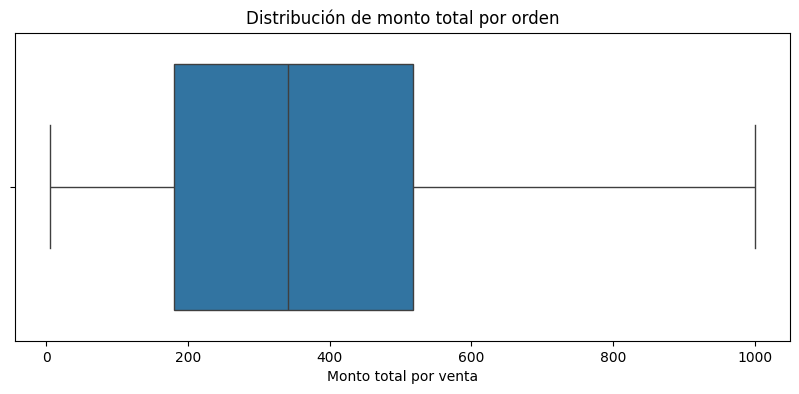

In [193]:
# Visual confirmation to justify using median for average ticket
plt.figure(figsize=(10, 4))
sns.boxplot(data=orders_clean, x='monto_total')
plt.xlabel('Monto total por venta')
plt.title('Distribución de monto total por orden')

### Ticket promedio por orden

- **Media:** $385.87
  
- **Mediana:** $341.41

Tras eliminar 10 filas con valores extremos de `cantidad` (10,000 o 20,000
unidades, detectadas como errores de captura), la diferencia entre media y
mediana se redujo significativamente, confirmado visualmente con un boxplot
que ya no muestra outliers extremos.

**Ticket promedio (usando mediana):** $341.41, como medida representativa
del comportamiento de compra típico.

In [194]:
# Compare mean vs median in 'cantidad'
print('Mean:')
print(orders_clean['cantidad'].mean())
print()

print('Median:')
print(orders_clean['cantidad'].median())

Mean:
1.5049326275264678

Median:
2.0


### Cantidad promedio de productos por orden

- Media: 1.50
- Mediana: 2.0

Ambas medidas están cerca entre sí, sin distorsión significativa, ya que los
valores extremos de `cantidad` (10,000 y 20,000 unidades) ya fueron
eliminados en la limpieza.

Cantidad promedio por orden: aproximadamente 1.5 a 2 productos, consistente
con el comportamiento esperado de compras individuales en una plataforma de
delivery.

In [195]:
# Group by 'nombre_producto' and sum 'cantidad' to find best-selling product
orders_clean.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)

,cantidad
nombre_producto,
Vacuum-Pro-Black,6284
Blender-XL-Red,6279
Jacket-Winter-M,6256
Sneakers-Urban-42,6172
Laptop-Gaming-16GB,4198
Tablet-Standard-64GB,4153
Phone-Pro-128GB,4140
Desconocido,45


### Producto más vendido

Se agruparon las ventas por `nombre_producto`, sumando `cantidad`:

- Vacuum-Pro-Black: 6,284 unidades
    
- Blender-XL-Red: 6,279 unidades
    
- Jacket-Winter-M: 6,256 unidades
    
- Sneakers-Urban-42: 6,172 unidades
    
- Laptop-Gaming-16GB: 4,198 unidades
    
- Tablet-Standard-64GB: 4,153 unidades
    
- Phone-Pro-128GB: 4,140 unidades
    
- Desconocido: 45 unidades (pedidos sin nombre de producto recuperable)

**Producto más vendido: Vacuum-Pro-Black**, con 6,284 unidades, aunque muy cerca de Blender-XL-Red y Jacket-Winter-M, mostrando alta paridad entre los  primeros 4 productos.

In [196]:
# Group by 'canal' and sum 'gasto' to find marketing spend by channel
marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending=False)

,gasto
canal,
social,918043.21
organic,913533.01
paid_search,863088.21
desconocido,177179.10


### Gasto en marketing por canal

Se agrupó el gasto por `canal`:

- Social: $918,043.21
  
- Organic: $913,533.01

  
- Paid search: $863,088.21

  
- Desconocido: $177,179.10

**Conclusión:** el gasto está distribuido de forma relativamente pareja entre
los 3 canales principales (social, organic, paid_search), sin una
concentración dominante en uno solo.

---

## 🔹 Paso 3: Funnel de conversión

Se conectó a la base de datos para consultar la tabla `events` vía SQL, se construyó el funnel calculando usuarios únicos por `nombre_evento` en cada etapa, y se calculó la tasa de conversión entre pasos para identificar en qué etapa se pierde la mayor cantidad de usuarios.

In [197]:
!pip install duckdb

import pandas as pd
import duckdb

# Local database loaded from CSV exports (previously PostgreSQL, ahora reproducible sin credenciales)
engine = duckdb.connect()

engine.execute("CREATE TABLE events AS SELECT * FROM read_csv_auto('events.csv')")
engine.execute("CREATE TABLE users AS SELECT * FROM read_csv_auto('users.csv')")
engine.execute("CREATE TABLE user_activity AS SELECT * FROM read_csv_auto('user_activity.csv')")

In [198]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events
LIMIT 10;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

/tmp/ipykernel_2320/3125225974.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events = pd.read_sql(query_events, con=engine)


,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [199]:
# Build funnel counting only users who completed the full sequence, in chronological order
query_funnel = '''
WITH etapas AS (
    SELECT
        id_usuario,
        MIN(CASE WHEN nombre_evento = 'first_visit' THEN timestamp_evento END) AS t_first_visit,
        MIN(CASE WHEN nombre_evento = 'select_item' THEN timestamp_evento END) AS t_select_item,
        MIN(CASE WHEN nombre_evento = 'add_to_cart' THEN timestamp_evento END) AS t_add_to_cart,
        MIN(CASE WHEN nombre_evento = 'begin_checkout' THEN timestamp_evento END) AS t_begin_checkout,
        MIN(CASE WHEN nombre_evento = 'add_payment_info' THEN timestamp_evento END) AS t_add_payment_info,
        MIN(CASE WHEN nombre_evento = 'purchase' THEN timestamp_evento END) AS t_purchase
    FROM events
    GROUP BY id_usuario
),
secuencia_valida AS (
    SELECT
        id_usuario,
        t_first_visit IS NOT NULL AS paso_1,
        (t_select_item IS NOT NULL AND t_select_item >= t_first_visit) AS paso_2,
        (t_add_to_cart IS NOT NULL AND t_add_to_cart >= t_select_item AND t_select_item IS NOT NULL) AS paso_3,
        (t_begin_checkout IS NOT NULL AND t_begin_checkout >= t_add_to_cart AND t_add_to_cart IS NOT NULL) AS paso_4,
        (t_add_payment_info IS NOT NULL AND t_add_payment_info >= t_begin_checkout AND t_begin_checkout IS NOT NULL) AS paso_5,
        (t_purchase IS NOT NULL AND t_purchase >= t_add_payment_info AND t_add_payment_info IS NOT NULL) AS paso_6
    FROM etapas
)
SELECT
    'first_visit' AS nombre_evento, SUM(CASE WHEN paso_1 THEN 1 ELSE 0 END) AS usuarios_unicos, 1 AS orden_evento FROM secuencia_valida
UNION ALL
SELECT 'select_item', SUM(CASE WHEN paso_1 AND paso_2 THEN 1 ELSE 0 END), 2 FROM secuencia_valida
UNION ALL
SELECT 'add_to_cart', SUM(CASE WHEN paso_1 AND paso_2 AND paso_3 THEN 1 ELSE 0 END), 3 FROM secuencia_valida
UNION ALL
SELECT 'begin_checkout', SUM(CASE WHEN paso_1 AND paso_2 AND paso_3 AND paso_4 THEN 1 ELSE 0 END), 4 FROM secuencia_valida
UNION ALL
SELECT 'add_payment_info', SUM(CASE WHEN paso_1 AND paso_2 AND paso_3 AND paso_4 AND paso_5 THEN 1 ELSE 0 END), 5 FROM secuencia_valida
UNION ALL
SELECT 'purchase', SUM(CASE WHEN paso_1 AND paso_2 AND paso_3 AND paso_4 AND paso_5 AND paso_6 THEN 1 ELSE 0 END), 6 FROM secuencia_valida
ORDER BY orden_evento;
'''
eventos_funnel = pd.read_sql(query_funnel, con=engine)
eventos_funnel

/tmp/ipykernel_2320/943593801.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eventos_funnel = pd.read_sql(query_funnel, con=engine)


,nombre_evento,usuarios_unicos,orden_evento
0,first_visit,7796,1
1,select_item,4118,2
2,add_to_cart,1342,3
3,begin_checkout,376,4
4,add_payment_info,92,5
5,purchase,10,6


#### Parte 1: Construcción del funnel

Se calcularon los usuarios únicos por cada etapa del funnel, ordenados según
el flujo lógico del usuario:

1. First visit: 7,796
2. Select item: 4,118
3. Add to cart: 1,342
4. Begin checkout: 376
5. Add payment info: 92
6. Purchase: 10

In [200]:
# Calculate users in current vs previous funnel stage
conversion_funnel = eventos_funnel.copy()
conversion_funnel['usuarios_anterior'] = conversion_funnel['usuarios_unicos'].shift(1)
conversion_funnel

,nombre_evento,usuarios_unicos,orden_evento,usuarios_anterior
0,first_visit,7796,1,NaN
1,select_item,4118,2,7796.0
2,add_to_cart,1342,3,4118.0
3,begin_checkout,376,4,1342.0
4,add_payment_info,92,5,376.0
5,purchase,10,6,92.0


In [201]:
# Calculate conversion rate between each funnel step (rounded to 2 decimals)
conversion_funnel['tasa_conversion'] = round(conversion_funnel['usuarios_unicos'] / conversion_funnel['usuarios_anterior'] * 100, 2)

In [202]:
# View funnel conversion rates
conversion_funnel

,nombre_evento,usuarios_unicos,orden_evento,usuarios_anterior,tasa_conversion
0,first_visit,7796,1,NaN,NaN
1,select_item,4118,2,7796.0,52.82
2,add_to_cart,1342,3,4118.0,32.59
3,begin_checkout,376,4,1342.0,28.02
4,add_payment_info,92,5,376.0,24.47
5,purchase,10,6,92.0,10.87


In [203]:
# Calculate overall funnel conversion rate (purchase vs first_visit) rounded to 2 decimals
round(conversion_funnel['usuarios_unicos'].iloc[-1] / conversion_funnel['usuarios_unicos'].iloc[0] * 100, 2)

np.float64(0.13)

#### Parte 2: Análisis de conversión

Se calculó la tasa de conversión entre cada etapa consecutiva del funnel:

- First visit → Select item: 52.82%
  
- Select item → Add to cart: 32.59%

- Add to cart → Begin checkout: 28.02%

- Begin checkout → Add payment info: 24.47%

- Add payment info → Purchase: 10.87%

**Mayor punto de pérdida:** entre "add payment info" y "purchase", donde se pierde un 89.13% de los usuarios que llegaron a esa etapa.

**Tasa de conversión final (first visit → purchase): 0.13%**

**Conclusión:** el funnel presenta una pérdida severa de usuarios en cada etapa, especialmente en el tramo final entre la captura de información de pago y la compra. Priorizar mejoras de UX en ese último tramo tendría el mayor impacto potencial sobre la conversión total.

---

## 🔹 Paso 4: Retención por cohortes

Usando las tablas `users` y `user_activity`, cada usuario fue asignado a una cohorte según su mes de registro, y se calculó la retención semanal (usuarios activos en las semanas 1, 2 y 3) como porcentaje de la cohorte inicial.

In [204]:
# Explore 'users' table
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

/tmp/ipykernel_2320/1010866305.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql(query_users, con=engine)


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [205]:
# Explore 'user_activity' table
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 10;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


/tmp/ipykernel_2320/3987997679.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_activity = pd.read_sql(query_user_activity, con=engine)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [206]:
# # Cohort retention analysis
# ======================
query_cohort_retention_final = '''
SELECT
    u.id_usuario,
   CAST(DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS DATE) AS cohorte,
    ua.dias_despues_registro / 7 AS semana,
    ua.activo
FROM users AS u
JOIN user_activity AS ua
    ON u.id_usuario = ua.id_usuario
'''
# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

/tmp/ipykernel_2320/3401251008.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)


,id_usuario,cohorte,semana,activo
0,user_0,2025-01-01,1.0,0
1,user_0,2025-01-01,2.0,1
2,user_0,2025-01-01,3.0,1
3,user_0,2025-01-01,4.0,0
4,user_1,2025-01-01,1.0,0
...,...,...,...,...
31995,user_7998,2025-05-01,4.0,1
31996,user_7999,2025-03-01,1.0,0
31997,user_7999,2025-03-01,2.0,1
31998,user_7999,2025-03-01,3.0,0


In [207]:
# Calculate retention percentage by cohort and week
query_cohort_retention_final = '''
WITH base AS (
    SELECT u.id_usuario, CAST(DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS DATE) AS cohorte, ua.dias_despues_registro / 7 AS semana, ua.activo
    FROM users AS u
    JOIN user_activity AS ua
    ON u.id_usuario = ua.id_usuario
),
retencion AS (
    SELECT cohorte, semana, COUNT(DISTINCT id_usuario) AS usuarios_activos
    FROM base
    WHERE activo = 1
    GROUP BY cohorte, semana
),
tamano_cohorte AS (
    SELECT cohorte, COUNT(DISTINCT id_usuario) AS usuarios_totales
    FROM base
    GROUP BY cohorte
)
SELECT r.cohorte, r.semana, ROUND(CAST(r.usuarios_activos AS NUMERIC) / t.usuarios_totales * 100, 2) AS porcentaje_retencion
FROM retencion AS r
JOIN tamano_cohorte AS t
    ON r.cohorte = t.cohorte
'''
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

/tmp/ipykernel_2320/3926044990.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)


,cohorte,semana,porcentaje_retencion
0,2025-02-01,1.0,42.31
1,2025-02-01,3.0,43.98
2,2025-01-01,4.0,41.24
3,2025-02-01,2.0,42.17
4,2025-05-01,4.0,40.25
5,2025-04-01,2.0,43.40
6,2025-03-01,1.0,41.38
7,2025-04-01,1.0,42.34
8,2025-04-01,3.0,41.28
9,2025-03-01,2.0,43.09


In [208]:
# Verify number of unique cohorts
cohorte_final['cohorte'].nunique()

5

In [209]:
# Convert to wide format (cohorte as rows, semana as columns)
cohorte_final.pivot(index='cohorte', columns='semana', values='porcentaje_retencion')

semana,1.0,2.0,3.0,4.0
cohorte,,,,
2025-01-01,42.84,41.06,40.32,41.24
2025-02-01,42.31,42.17,43.98,39.82
2025-03-01,41.38,43.09,42.18,41.14
2025-04-01,42.34,43.40,41.28,40.60
2025-05-01,41.20,40.07,41.85,40.25


#### Tabla de retención (formato ancho)

Se transformó el resultado a formato ancho, con cohortes en filas y semanas:

| Cohorte | Semana 1 | Semana 2 | Semana 3 | Semana 4 |
|---|---|---|---|---|
| Enero 2025 | 42.84% | 41.06% | 40.32% | 41.24% |
| Febrero 2025 | 42.31% | 42.17% | 43.98% | 39.82% |
| Marzo 2025 | 41.38% | 43.09% | 42.18% | 41.14% |
| Abril 2025 | 42.34% | 43.40% | 41.28% | 40.60% |
| Mayo 2025 | 41.20% | 40.07% | 41.85% | 40.25% |

**Conclusión:** la retención se mantiene estable (~40-44%) en las 4 semanas y las 5 cohortes, sin un patrón de abandono progresivo. Los usuarios que permanecen activos lo hacen de forma consistente durante todo el primer mes.

---

## 🔹 Paso 5: Test estadístico del checkout

Se analizó el dataset `experiment_checkout_ui.csv` para evaluar si una modificación en la UI del checkout impacta la tasa de conversión de compra, planteando y validando la hipótesis estadística correspondiente.

In [210]:
# Load 'experiment' dataset
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [211]:
# Explore 'experiment' dataset
print('Experiment Dataset:')
print()
print('Shape:')
print(experiment.shape)
print()
print('Info:')
experiment.info()
print()
print('Sample:')
experiment.head(10)

Experiment Dataset:

Shape:
(10000, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB

Sample:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12
5,exp_user_5,control,0,mobile,Mexico,206.70,2025-01-26
6,exp_user_6,control,0,desktop,Mexico,280.11,2025-04-15
7,exp_user_7,tratamiento,0,mobile,Argentina,28.47,2025-03-18
8,exp_user_8,tratamiento,0,desktop,Mexico,287.04,2025-02-05
9,exp_user_9,control,0,mobile,Argentina,258.91,2025-02-11


In [212]:
# Check distribution of 'variante' groups
usuarios_por_grupo = experiment['variante'].value_counts()
print('Distribución de variante:')
print(usuarios_por_grupo)

Distribución de variante:
variante
tratamiento    5035
control        4965
Name: count, dtype: int64


In [213]:
# Calculate conversion rate by group
print('Tasa de conversión por variante:')
print(round(100 * experiment.groupby('variante')['convirtio'].mean(), 2))

Tasa de conversión por variante:
variante
control        15.69
tratamiento    16.29
Name: convirtio, dtype: float64


#### Parte 1: Exploración y calidad de los datos
Se revisó la estructura y calidad del dataset `experiment_checkout_ui.csv` antes de plantear el test estadístico:
- El dataset contiene 10,000 filas y 7 columnas, sin valores nulos en ninguna de ellas.
  
- `variante`: 4,965 usuarios en `control` y 5,035 en `tratamiento`, una distribución balanceada entre grupos.

  
- `convirtio`: sin valores fuera de {0, 1}, consistente con la métrica de conversión esperada.

**Conclusión:** no hay problemas de calidad de datos ni desbalance entre grupos que comprometan la comparación.

#### Parte 2: Tasa de conversión por variante
Se calculó la tasa de conversión (`convirtio`) dentro de cada grupo del experimento:
- `control`: 15.69% de conversión.
  
- `tratamiento`: 16.29% de conversión.

**Diferencia observada:** 0.6 puntos porcentuales a favor de `tratamiento`.

**Conclusión:** la diferencia es pequeña y podría deberse a variabilidad muestral. Se requiere un test estadístico formal (H₀/H₁, α = 0.05) para determinar si es estadísticamente significativa o es producto del azar.

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No existe una diferencia estadísticamente significativa entre la tasa de conversión del grupo control y la del grupo tratamiento (p_control = p_tratamiento).
   - **H₁ (Hipótesis alternativa):**  Existe una diferencia estadísticamente significativa entre la tasa de conversión del grupo control y la del grupo tratamiento (p_control ≠ p_tratamiento).
   
**Test estadístico:** Z-test de Proporciones
**Nivel de significancia alpha:** 0.05

In [214]:
# Calculate number of conversions by group
conversiones_por_grupo = experiment.groupby('variante')['convirtio'].sum()
print('Número de conversiones por variante:')
print(conversiones_por_grupo)

Número de conversiones por variante:
variante
control        779
tratamiento    820
Name: convirtio, dtype: int64


In [215]:
# Prepare counts and sample sizes for z-test
count = [conversiones_por_grupo['tratamiento'], conversiones_por_grupo['control']]
nobs = [usuarios_por_grupo['tratamiento'], usuarios_por_grupo['control']]

In [216]:
# Perform two-proportion z-test
z_stat, p_value = proportions_ztest(count, nobs)
print('Estadístico z:', z_stat)
print('P-value:', p_value)

Estadístico z: 0.8132782986429474
P-value: 0.41605851639119995


### Resultado del experimento
Con base en los resultados obtenidos mediante la prueba Z-test (p-value = 0.416, α = 0.05), no se encontró evidencia estadísticamente significativa de que exista una diferencia real en la tasa de conversión entre los grupos `control` (15.69%) y `tratamiento` (16.29%). La diferencia observada es consistente con variabilidad muestral.

### Recomendación
No se recomienda implementar el nuevo diseño de checkout en este momento, dada la inversión que esto representaría sin evidencia sólida de mejora en la
conversión. Se sugiere repetir la prueba con un tamaño de muestra mayor: con solo 10,000 usuarios y una diferencia observada tan pequeña (0.6 puntos porcentuales), es posible que el test actual no tenga suficiente **poder estadístico** para detectar una diferencia real entre variantes, en caso de que exista. Un experimento con mayor tamaño de muestra permitiría estimar las tasas de conversión con mayor precisión y aumentaría la capacidad del test
para identificar efectos reales, si los hubiera.

---

## 🔹 Paso 6: Dashboard en Power BI

Los tres datasets limpios se cargaron en Power BI para construir un dashboard con los KPIs principales (revenue, profit, marketing, ticket promedio, unidades por pedido), visualizaciones de tendencia y comparación por categoría, navegación entre páginas y un detalle por producto mediante drill-through.

### Hallazgos y recomendaciones del Dashboard

**1. Rentabilidad negativa en dos productos, pese a ventas altas**

`Jacket-Winter-M` y `Laptop-Gaming-16GB` muestran profit prorrateado negativo (`-$57,235.12` y `-$417,350.61` respectivamente), a pesar de estar entre los productos con mayor volumen de ventas. En ambos casos, el costo total (aproximadamente `$1.18M` cada uno) representa casi la totalidad del revenue generado, dejando un margen insuficiente para cubrir el resto de los costos operativos, incluido el marketing prorrateado.

**Recomendación:** priorizar la revisión de la estructura de costo y precio de venta de estos dos productos. Son los únicos con margen negativo del catálogo, y su alto volumen de ventas amplifica el impacto financiero de ese margen insuficiente.

**2. 45 pedidos con producto no identificable ("Desconocido" / "Sin categoría")**

45 unidades (0.12% del total vendido, `$12,262.62` en revenue) no pudieron vincularse a ningún producto ni categoría del catálogo durante la limpieza de datos.

**Recomendación:** investigar en el sistema de origen por qué estos registros no capturaron el nombre del producto correctamente, para prevenir que el problema continúe afectando futuros reportes.

### Conclusión general: salud del negocio

Con un Revenue de `$9.62M`, Costo de `$3.83M`, Marketing de `$2.87M` y Profit Neto de `$2.92M` (aproximadamente 30% de margen), el negocio es rentable de forma consolidada, aunque el desempeño no es uniforme entre productos: los dos casos descritos en el primer hallazgo concentran pérdida, mientras el resto mantiene márgenes saludables.

**Por categoría:** Hogar (`$3.23M`), Electrónica (`$3.20M`) y Moda (`$3.17M`) muestran una paridad muy alta entre sí. Ninguna categoría domina claramente sobre las otras, lo que sugiere una cartera de productos balanceada en lugar de dependencia de una sola línea de negocio.

**Por mes:** el revenue se mantiene relativamente estable, entre `$1.44M` y `$1.66M` mensuales, sin una tendencia de crecimiento o caída sostenida a lo largo del semestre. La única variación notable es febrero, con el mes más bajo tanto en revenue (`$1.44M`) como en unidades vendidas (5,658, frente a un promedio cercano a 6,300 en los demás meses), posiblemente un efecto estacional que valdría la pena contrastar con el mismo periodo del año anterior si se dispusiera de esos datos.

🔗 [Descargar dashboard (.pbix) y CSVs limpios en Google Drive](https://drive.google.com/drive/folders/1E6tyQ_wmgoAgn7QDM-e2uzmKT-6JRm_J?usp=sharing)